In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv')

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


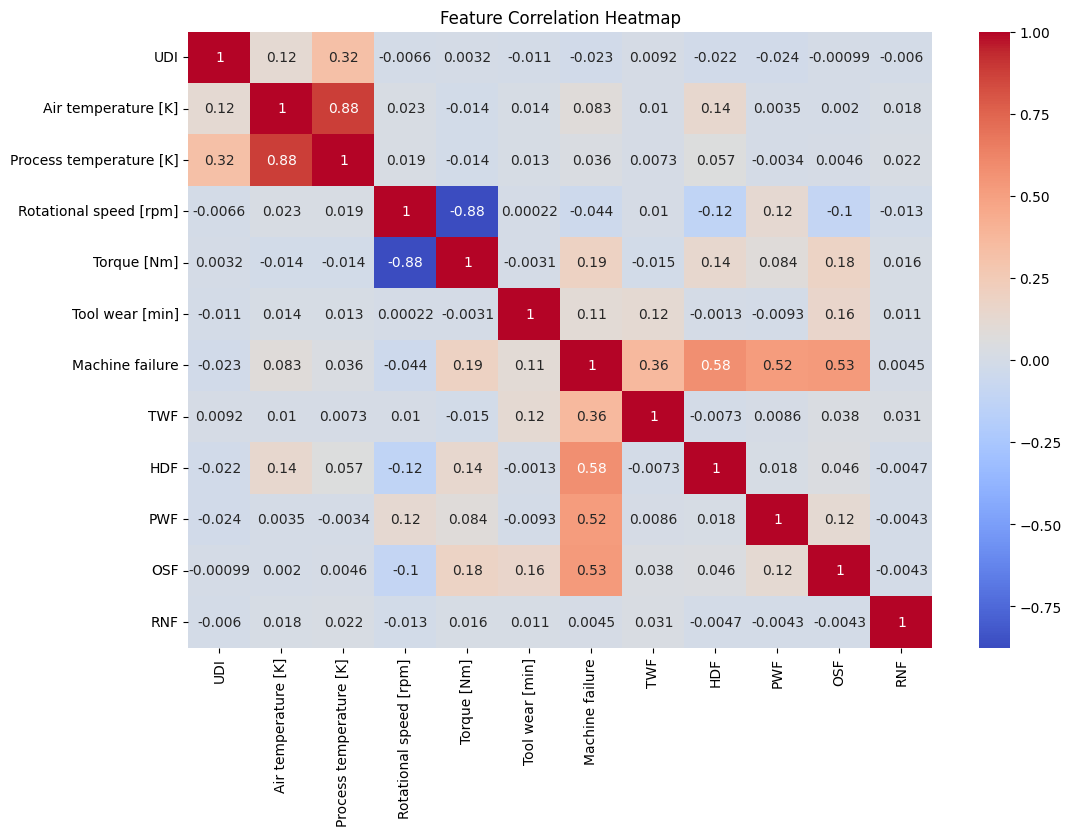

In [3]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

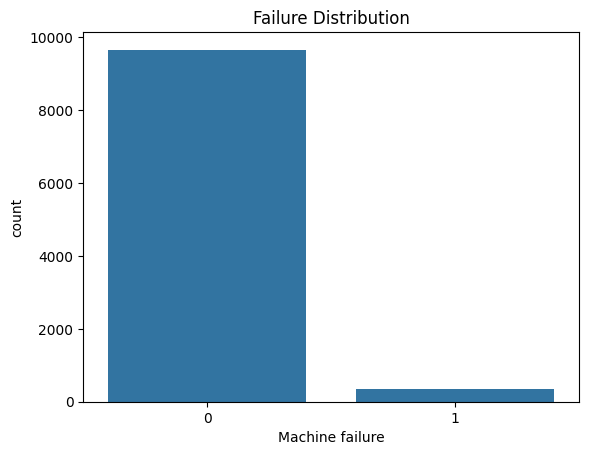

In [4]:
sns.countplot(x=df['Machine failure'])

plt.title("Failure Distribution")

plt.show()

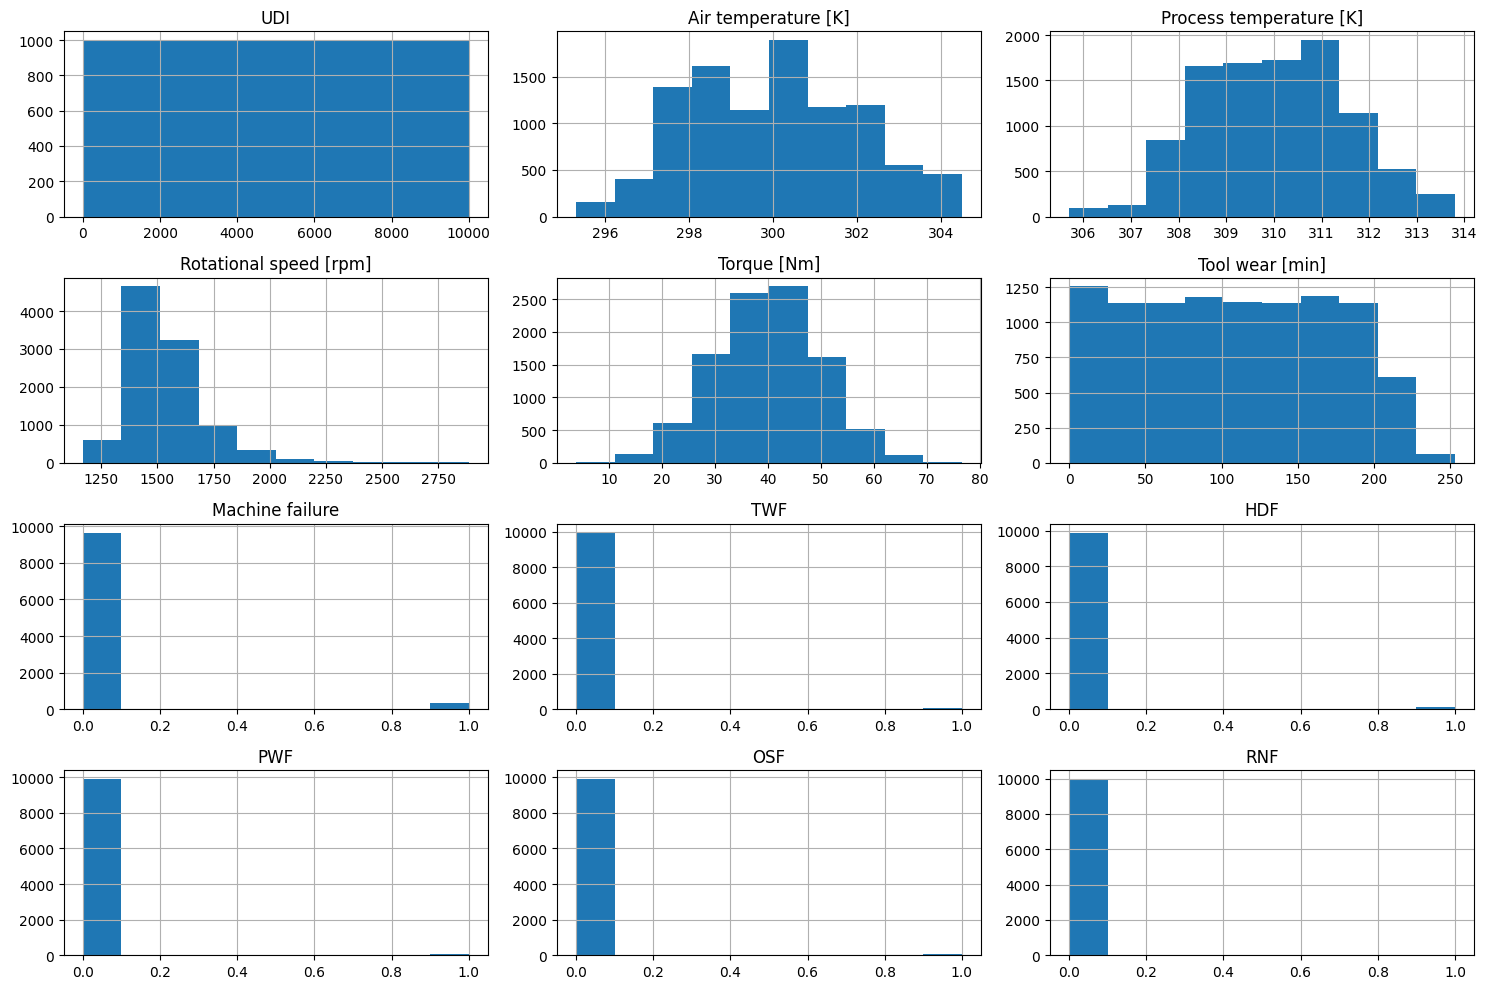

In [5]:
df.hist(figsize=(15,10))

plt.tight_layout()

plt.show()

In [6]:
window_size = 10

df['torque_roll_mean'] = (
    df['Torque [Nm]']
    .rolling(window=window_size)
    .mean()
)

df['rot_speed_roll_std'] = (
    df['Rotational speed [rpm]']
    .rolling(window=window_size)
    .std()
)

df['air_temp_roll_min'] = (
    df['Air temperature [K]']
    .rolling(window=window_size)
    .min()
)

df['process_temp_roll_max'] = (
    df['Process temperature [K]']
    .rolling(window=window_size)
    .max()
)

In [7]:
df = df.dropna()

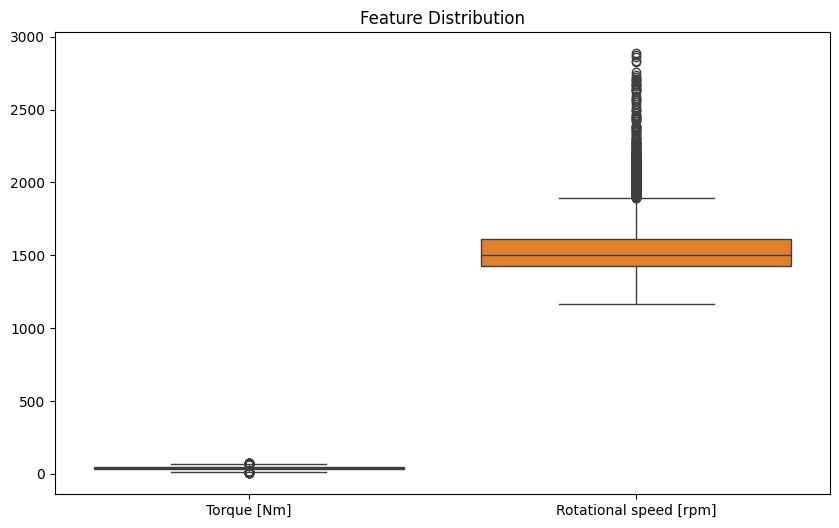

In [8]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df[['Torque [Nm]', 'Rotational speed [rpm]']])

plt.title("Feature Distribution")

plt.show()